<a href="https://colab.research.google.com/github/00abhinav-u/00abhinav-u/blob/main/Employee_Retention_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Employee Retention Prediction Using Machine Learning</h1>

<h2>Context</h2>
<p>
A company active in Big Data and Data Science wants to hire data scientists from candidates
who successfully pass their training courses. The company wants to understand which
candidates are <strong>likely to stay</strong> with the company after training and which ones
are <strong>looking for a new job</strong>. This helps in reducing costs, improving training
quality, and planning HR decisions.
</p>

<h2>Objective</h2>
<p>
Build a classification model to predict whether an employee will <strong>leave</strong>
(target = 1) or <strong>stay</strong> (target = 0) based on their demographic, education,
and experience features. We will compare the performance of three models:
<strong>Logistic Regression</strong>, <strong>Random Forest</strong>, and
<strong>Gradient Boosting</strong>.
</p>

<h2>Data Description</h2>
<p><strong>Training set:</strong> 19,158 observations | <strong>Test set:</strong> 2,129 observations | <strong>14 variables</strong></p>

<ul>
  <li><strong>enrollee_id:</strong> Unique ID for each candidate</li>
  <li><strong>city:</strong> City code of the candidate</li>
  <li><strong>city_development_index:</strong> Development index of the city (scaled 0 to 1)</li>
  <li><strong>gender:</strong> Gender of the candidate — <em>Male, Female, Other</em></li>
  <li><strong>relevent_experience:</strong> Whether the candidate has relevant work experience — <em>Has relevent experience, No relevent experience</em></li>
  <li><strong>enrolled_university:</strong> Type of university enrollment — <em>no_enrollment, Full time course, Part time course</em></li>
  <li><strong>education_level:</strong> Education level of the candidate — <em>Graduate, Masters, High School, Phd, Primary School</em></li>
  <li><strong>major_discipline:</strong> Major discipline of the candidate — <em>STEM, Humanities, Business Degree, Arts, Other, No Major</em></li>
  <li><strong>experience:</strong> Total years of experience of the candidate</li>
  <li><strong>company_size:</strong> Number of employees in the current company</li>
  <li><strong>company_type:</strong> Type of current employer — <em>Pvt Ltd, Funded Startup, Public Sector, Early Stage Startup, NGO, Other</em></li>
  <li><strong>last_new_job:</strong> Years since the candidate's last job change</li>
  <li><strong>training_hours:</strong> Total training hours completed</li>
  <li><strong>target:</strong> <em>0</em> = Not looking for job change (Stay), <em>1</em> = Looking for job change (Leave)</li>
</ul>

<h2>🔧 Setup & Imports</h2>

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

from collections import Counter

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully!")

All libraries imported successfully!


<h2>📂 Load & Inspect Data</h2>

In [ ]:
# Load the datasets
train_df = pd.read_csv("aug_train.csv")
test_df = pd.read_csv("aug_test.csv")

print("Training set shape:", train_df.shape)
print("Test set shape:    ", test_df.shape)

Training set shape: (19158, 14)
Test set shape:     (2129, 13)


In [ ]:
# First look at the training data
train_df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [ ]:
# Data types and non-null counts
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [ ]:
# Statistical summary of numeric columns
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,16875.358179,9616.292592,1.000,8554.25,16982.500,25169.75,33380.000
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


In [ ]:
# Missing values analysis
missing = pd.DataFrame({
    'Missing Count': train_df.isnull().sum(),
    'Missing %': (train_df.isnull().sum() / len(train_df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Columns with missing values: {len(missing)}")
missing

Columns with missing values: 8


,Missing Count,Missing %
company_type,6140,32.05
company_size,5938,30.99
gender,4508,23.53
major_discipline,2813,14.68
education_level,460,2.40
last_new_job,423,2.21
enrolled_university,386,2.01
experience,65,0.34


In [ ]:
# Unique values for each column
for col in train_df.columns:
    print(f"{col:30s} | dtype: {str(train_df[col].dtype):8s} | unique: {train_df[col].nunique():5d} | nulls: {train_df[col].isnull().sum()}")

enrollee_id                    | dtype: int64    | unique: 19158 | nulls: 0
city                           | dtype: object   | unique:   123 | nulls: 0
city_development_index         | dtype: float64  | unique:    93 | nulls: 0
gender                         | dtype: object   | unique:     3 | nulls: 4508
relevent_experience            | dtype: object   | unique:     2 | nulls: 0
enrolled_university            | dtype: object   | unique:     3 | nulls: 386
education_level                | dtype: object   | unique:     5 | nulls: 460
major_discipline               | dtype: object   | unique:     6 | nulls: 2813
experience                     | dtype: object   | unique:    22 | nulls: 65
company_size                   | dtype: object   | unique:     8 | nulls: 5938
company_type                   | dtype: object   | unique:     6 | nulls: 6140
last_new_job                   | dtype: object   | unique:     6 | nulls: 423
training_hours                 | dtype: int64    | unique:   241 | nu

<h2>🧹 Data Cleaning</h2>

In [ ]:
# Check for duplicate rows
duplicates = train_df.duplicated().sum()
print(f"Duplicate rows in training set: {duplicates}")

# Drop enrollee_id (unique identifier, not a feature)
train_df.drop('enrollee_id', axis=1, inplace=True)
test_ids = test_df['enrollee_id']  # Save for later predictions
test_df.drop('enrollee_id', axis=1, inplace=True)

print(f"Training shape after dropping ID: {train_df.shape}")
print(f"Test shape after dropping ID: {test_df.shape}")

Duplicate rows in training set: 0
Training shape after dropping ID: (19158, 13)
Test shape after dropping ID: (2129, 12)


In [ ]:
# Handle missing values
# Strategy: fill categorical with 'Unknown', numeric with median

# Categorical columns with missing values
cat_cols_missing = ['gender', 'enrolled_university', 'education_level',
                    'major_discipline', 'company_size', 'company_type',
                    'last_new_job', 'experience']

for col in cat_cols_missing:
    train_df[col] = train_df[col].fillna('Unknown')
    test_df[col] = test_df[col].fillna('Unknown')

# Verify no missing values remain
print("Missing values after cleaning:")
print(f"  Train: {train_df.isnull().sum().sum()}")
print(f"  Test:  {test_df.isnull().sum().sum()}")

Missing values after cleaning:
  Train: 0
  Test:  0


<h2>📊 Exploratory Data Analysis</h2>

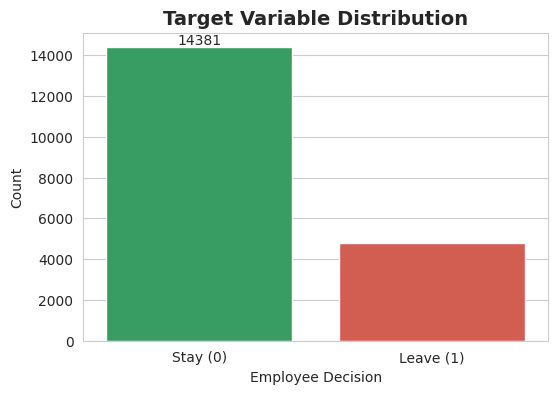

Stay:  14381 (75.1%)
Leave: 4777 (24.9%)

The dataset is imbalanced — ~75% Stay vs ~25% Leave.


In [ ]:
# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
colors = ['#27ae60', '#e74c3c']
ax = sns.countplot(data=train_df, x='target', palette=colors)
ax.bar_label(ax.containers[0])
ax.set_xticklabels(['Stay (0)', 'Leave (1)'])
plt.title('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Employee Decision')
plt.ylabel('Count')
plt.show()

print(f"Stay:  {(train_df['target']==0).sum()} ({(train_df['target']==0).mean()*100:.1f}%)")
print(f"Leave: {(train_df['target']==1).sum()} ({(train_df['target']==1).mean()*100:.1f}%)")
print("\nThe dataset is imbalanced — ~75% Stay vs ~25% Leave.")

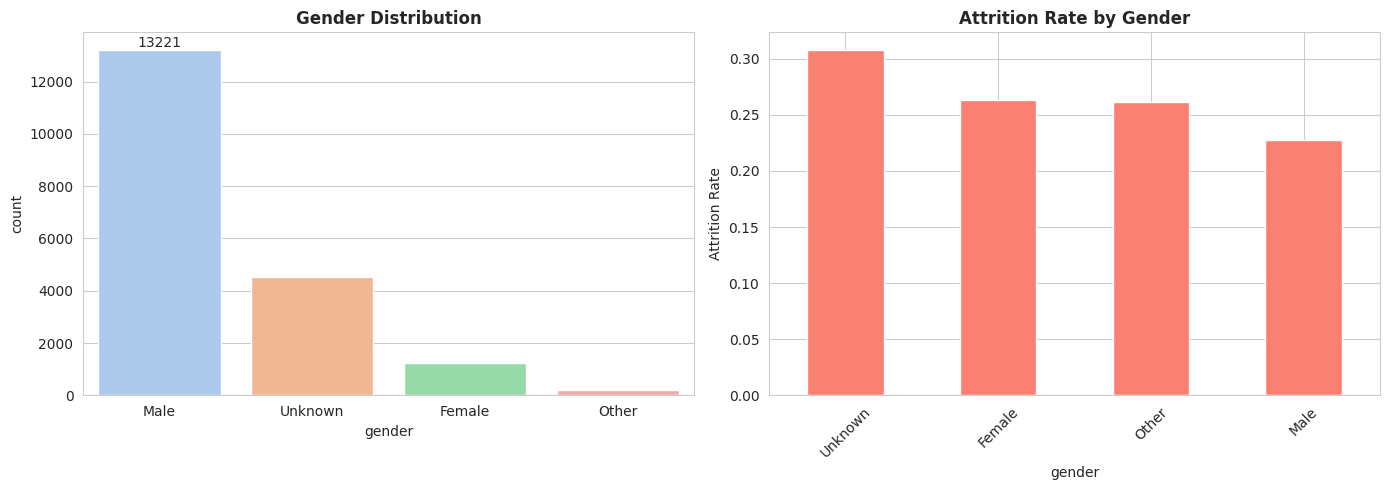

In [ ]:
# 2. Gender Distribution & Retention
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender count
ax1 = sns.countplot(data=train_df, x='gender', palette='pastel', ax=axes[0])
ax1.bar_label(ax1.containers[0])
axes[0].set_title('Gender Distribution', fontweight='bold')

# Gender vs Target
gender_target = train_df.groupby('gender')['target'].mean().sort_values(ascending=False)
gender_target.plot(kind='bar', color='salmon', ax=axes[1])
axes[1].set_title('Attrition Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

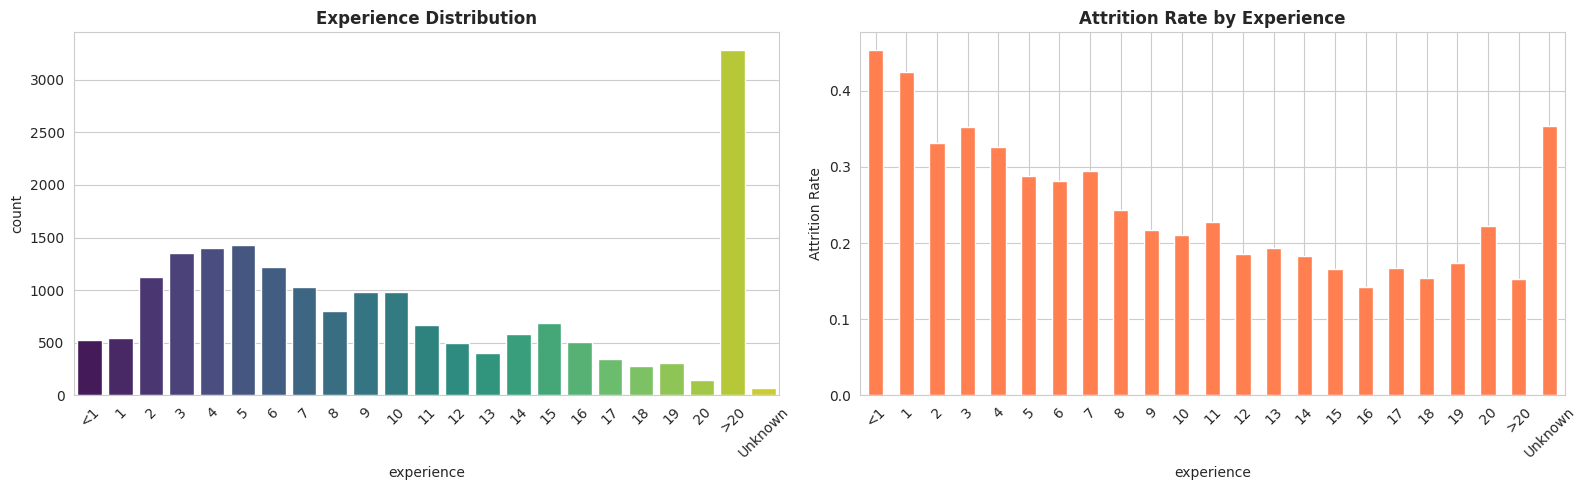

In [ ]:
# 3. Experience vs Retention
# Sort experience values properly
exp_order = ['<1', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
             '12', '13', '14', '15', '16', '17', '18', '19', '20', '>20', 'Unknown']
exp_in_data = [e for e in exp_order if e in train_df['experience'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=train_df, x='experience', order=exp_in_data, palette='viridis', ax=axes[0])
axes[0].set_title('Experience Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

exp_attrition = train_df.groupby('experience')['target'].mean().reindex(exp_in_data)
exp_attrition.plot(kind='bar', color='coral', ax=axes[1])
axes[1].set_title('Attrition Rate by Experience', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

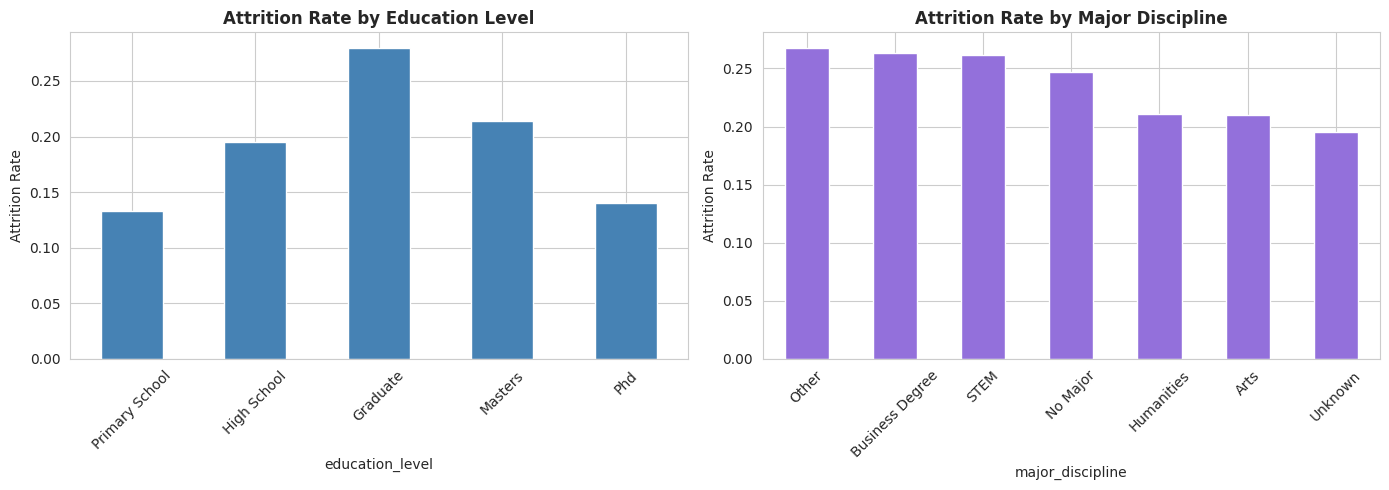

In [ ]:
# 4. Education Level & Major Discipline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_order = ['Primary School', 'High School', 'Graduate', 'Masters', 'Phd']
edu_in_data = [e for e in edu_order if e in train_df['education_level'].unique()]
edu_attrition = train_df.groupby('education_level')['target'].mean().reindex(edu_in_data)
edu_attrition.plot(kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('Attrition Rate by Education Level', fontweight='bold')
axes[0].set_ylabel('Attrition Rate')
axes[0].tick_params(axis='x', rotation=45)

major_attrition = train_df.groupby('major_discipline')['target'].mean().sort_values(ascending=False)
major_attrition.plot(kind='bar', color='mediumpurple', ax=axes[1])
axes[1].set_title('Attrition Rate by Major Discipline', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

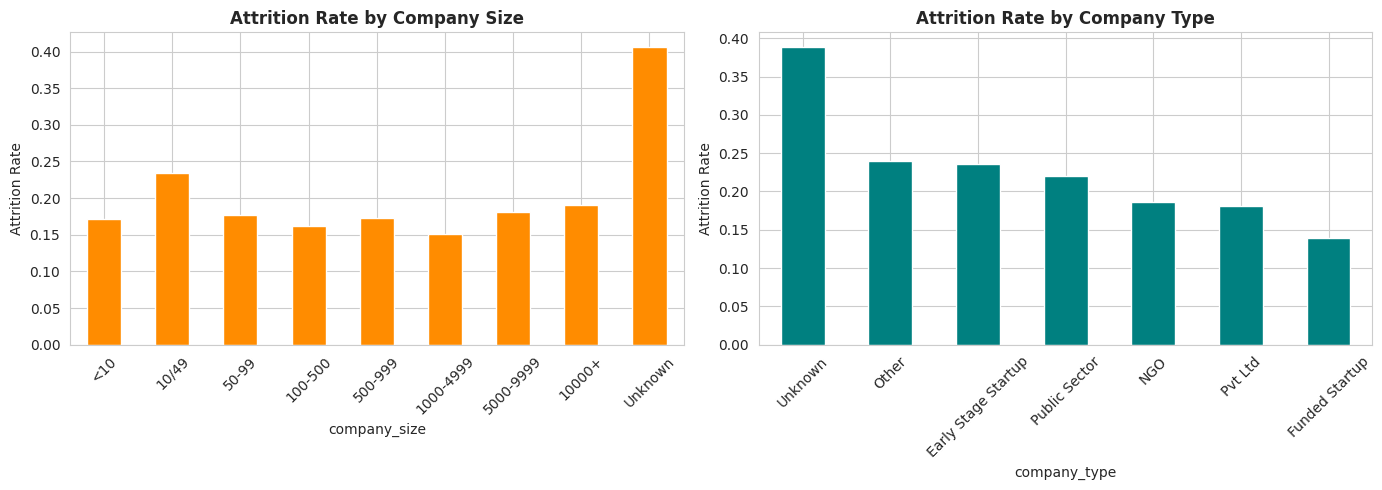

In [ ]:
# 5. Company Size & Type vs Retention
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

size_order = ['<10', '10/49', '50-99', '100-500', '500-999', '1000-4999', '5000-9999', '10000+', 'Unknown']
size_in_data = [s for s in size_order if s in train_df['company_size'].unique()]
size_attrition = train_df.groupby('company_size')['target'].mean().reindex(size_in_data)
size_attrition.plot(kind='bar', color='darkorange', ax=axes[0])
axes[0].set_title('Attrition Rate by Company Size', fontweight='bold')
axes[0].set_ylabel('Attrition Rate')
axes[0].tick_params(axis='x', rotation=45)

type_attrition = train_df.groupby('company_type')['target'].mean().sort_values(ascending=False)
type_attrition.plot(kind='bar', color='teal', ax=axes[1])
axes[1].set_title('Attrition Rate by Company Type', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

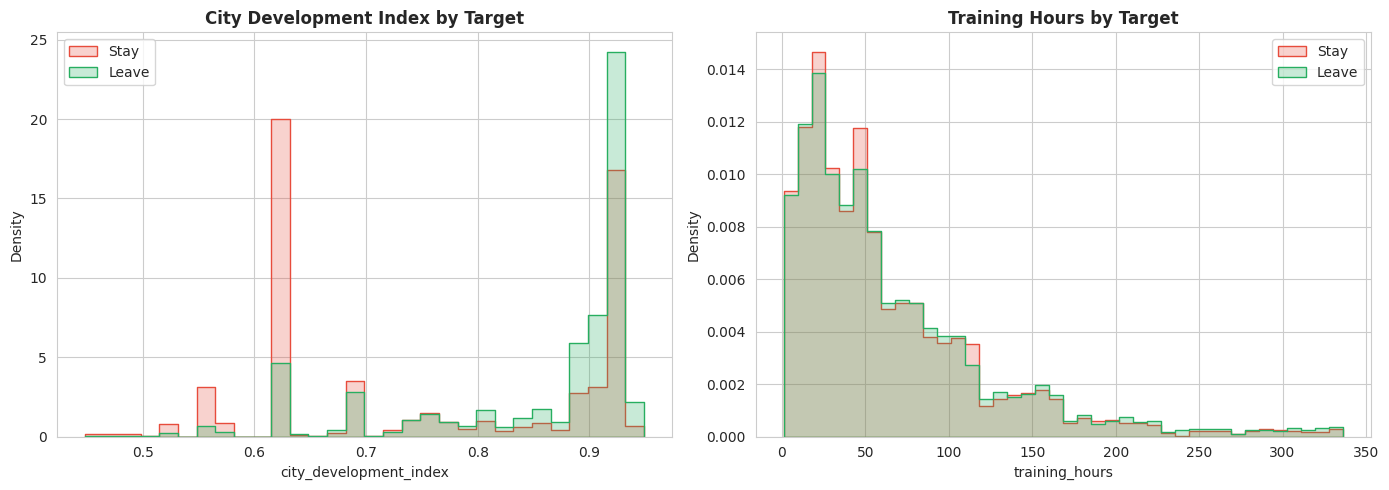

In [ ]:
# 6. City Development Index & Training Hours
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train_df, x='city_development_index', hue='target',
             bins=30, element='step', stat='density', common_norm=False,
             palette=colors, ax=axes[0])
axes[0].set_title('City Development Index by Target', fontweight='bold')
axes[0].legend(['Stay', 'Leave'])

sns.histplot(data=train_df, x='training_hours', hue='target',
             bins=40, element='step', stat='density', common_norm=False,
             palette=colors, ax=axes[1])
axes[1].set_title('Training Hours by Target', fontweight='bold')
axes[1].legend(['Stay', 'Leave'])

plt.tight_layout()
plt.show()

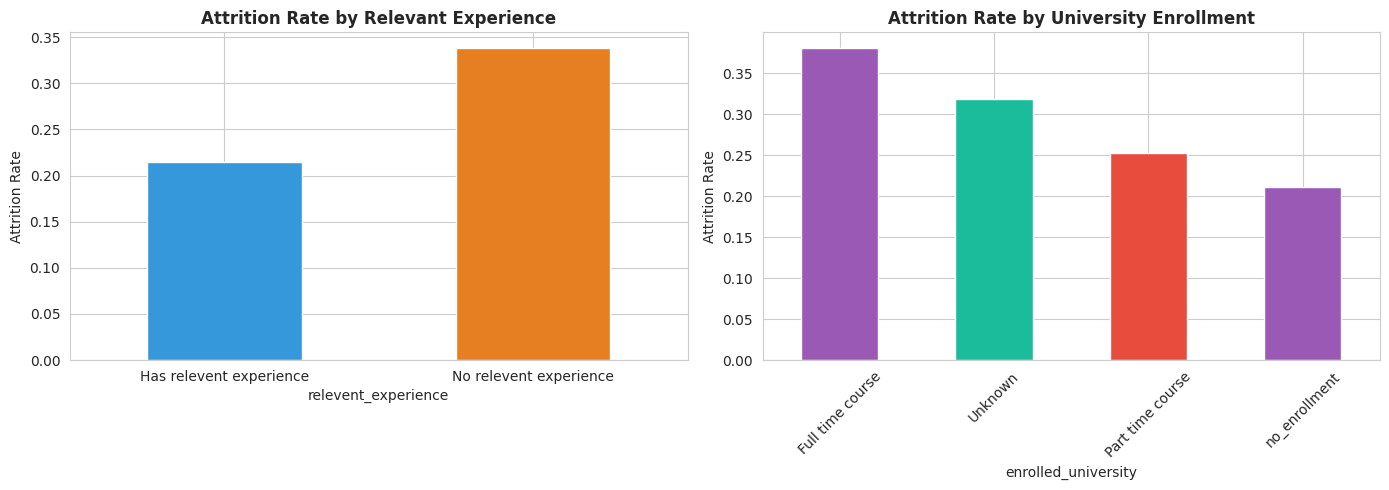

In [ ]:
# 7. Relevant Experience & University Enrollment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_target = train_df.groupby('relevent_experience')['target'].mean()
exp_target.plot(kind='bar', color=['#3498db', '#e67e22'], ax=axes[0])
axes[0].set_title('Attrition Rate by Relevant Experience', fontweight='bold')
axes[0].set_ylabel('Attrition Rate')
axes[0].tick_params(axis='x', rotation=0)

uni_target = train_df.groupby('enrolled_university')['target'].mean().sort_values(ascending=False)
uni_target.plot(kind='bar', color=['#9b59b6', '#1abc9c', '#e74c3c'], ax=axes[1])
axes[1].set_title('Attrition Rate by University Enrollment', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

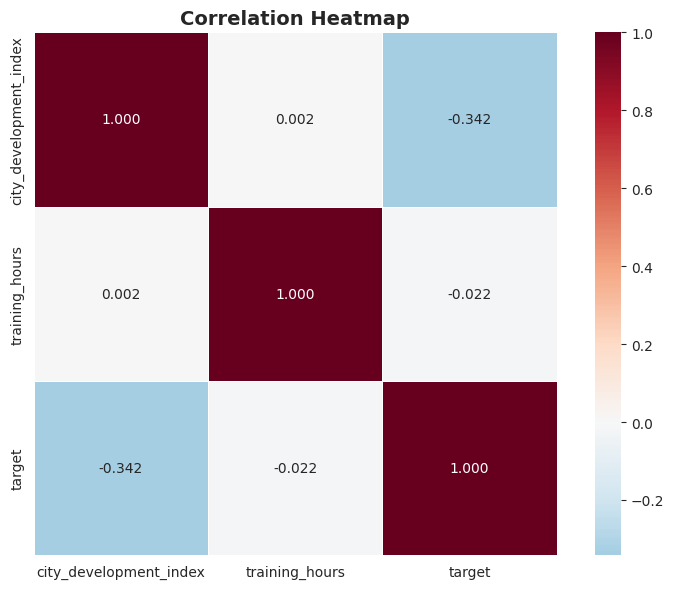

In [ ]:
# 8. Correlation Heatmap (numeric features)
numeric_df = train_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h2>⚙️ Feature Engineering & Preprocessing</h2>

In [ ]:
# Label Encode all categorical columns
# We apply the same encoding to both train and test sets

label_encoders = {}
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined train + test to handle all possible values
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} classes encoded")

print(f"\nTraining set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Categorical columns to encode: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']
  city: 123 classes encoded
  gender: 4 classes encoded
  relevent_experience: 2 classes encoded
  enrolled_university: 4 classes encoded
  education_level: 6 classes encoded
  major_discipline: 7 classes encoded
  experience: 23 classes encoded
  company_size: 9 classes encoded
  company_type: 7 classes encoded
  last_new_job: 7 classes encoded

Training set shape: (19158, 13)
Test set shape: (2129, 12)


In [ ]:
# Verify all columns are numeric now
print("Training dtypes:")
print(train_df.dtypes)
print(f"\nAny non-numeric: {train_df.select_dtypes(include='object').shape[1] > 0}")

Training dtypes:
city                        int64
city_development_index    float64
gender                      int64
relevent_experience         int64
enrolled_university         int64
education_level             int64
major_discipline            int64
experience                  int64
company_size                int64
company_type                int64
last_new_job                int64
training_hours              int64
target                    float64
dtype: object

Any non-numeric: False


<h2>🔄 Train-Validation Split</h2>
<p>Since the provided test set (<code>aug_test.csv</code>) does not contain the target variable,
we split the training data into <strong>80% training</strong> and <strong>20% validation</strong>
for model evaluation. The test set will be used for final predictions.</p>

In [ ]:
# Separate features and target
X = train_df.drop('target', axis=1)
y = train_df['target'].astype(int)

# Stratified train-validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"\nTraining class distribution:   {dict(Counter(y_train))}")
print(f"Validation class distribution: {dict(Counter(y_val))}")

Training set:   (15326, 12)
Validation set: (3832, 12)

Training class distribution:   {0: 11504, 1: 3822}
Validation class distribution: {0: 2877, 1: 955}


In [ ]:
# Feature Scaling
# Logistic Regression benefits from scaled features; tree-based models don't need it
# but we'll use scaled data for all models for consistency

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test_df)

print("Feature scaling complete.")
print(f"Scaled training shape:   {X_train_scaled.shape}")
print(f"Scaled validation shape: {X_val_scaled.shape}")
print(f"Scaled test shape:       {X_test_scaled.shape}")

Feature scaling complete.
Scaled training shape:   (15326, 12)
Scaled validation shape: (3832, 12)
Scaled test shape:       (2129, 12)


<h2>🤖 Model Training & Comparison</h2>
<p>We train three classification models and compare their performance:</p>
<ol>
  <li><strong>Logistic Regression</strong> — a simple linear baseline</li>
  <li><strong>Random Forest</strong> — an ensemble of decision trees</li>
  <li><strong>Gradient Boosting</strong> — a sequential ensemble method</li>
</ol>

In [ ]:
# Helper function to train, evaluate, and store results
results = {}
models = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train a model, evaluate on validation set, and store results."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    results[name] = {'accuracy': acc, 'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}
    models[name] = model

    print(f"{'='*60}")
    print(f"  {name}")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred, target_names=['Stay', 'Leave']))
    return y_pred

In [ ]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
evaluate_model("Logistic Regression", lr, X_train_scaled, X_val_scaled, y_train, y_val);

  Logistic Regression
  Accuracy: 0.7294 (72.94%)
  AUC-ROC:  0.7802
              precision    recall  f1-score   support

        Stay       0.90      0.72      0.80      2877
       Leave       0.47      0.75      0.58       955

    accuracy                           0.73      3832
   macro avg       0.68      0.74      0.69      3832
weighted avg       0.79      0.73      0.75      3832



In [ ]:
# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluate_model("Random Forest", rf, X_train_scaled, X_val_scaled, y_train, y_val);

  Random Forest
  Accuracy: 0.7972 (79.72%)
  AUC-ROC:  0.8074
              precision    recall  f1-score   support

        Stay       0.90      0.82      0.86      2877
       Leave       0.57      0.72      0.64       955

    accuracy                           0.80      3832
   macro avg       0.74      0.77      0.75      3832
weighted avg       0.82      0.80      0.80      3832



In [ ]:
# 3. Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_split=5,
    random_state=42
)
evaluate_model("Gradient Boosting", gb, X_train_scaled, X_val_scaled, y_train, y_val);

  Gradient Boosting
  Accuracy: 0.7918 (79.18%)
  AUC-ROC:  0.8121
              precision    recall  f1-score   support

        Stay       0.86      0.87      0.86      2877
       Leave       0.59      0.56      0.57       955

    accuracy                           0.79      3832
   macro avg       0.72      0.72      0.72      3832
weighted avg       0.79      0.79      0.79      3832



<h2>📊 Model Comparison</h2>

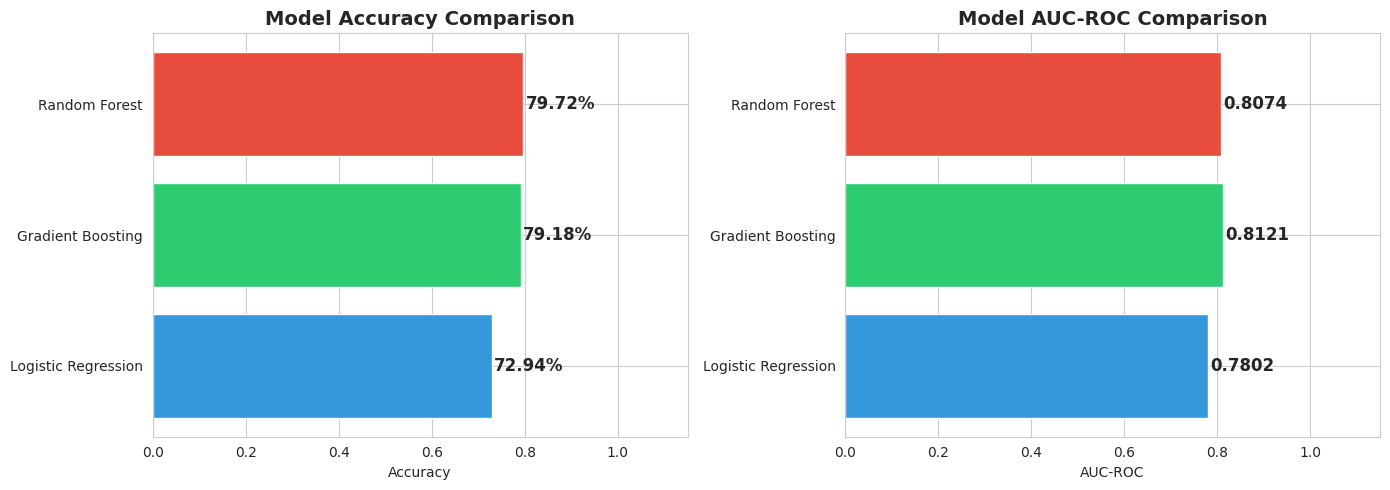


Model Comparison Summary:
Model                         Accuracy      AUC-ROC
-------------------------------------------------------
Random Forest                   79.72%       0.8074
Gradient Boosting               79.18%       0.8121
Logistic Regression             72.94%       0.7802


In [ ]:
# Accuracy Comparison
comparison = pd.DataFrame({
    'Model': [name for name in results],
    'Accuracy': [results[name]['accuracy'] for name in results],
    'AUC-ROC': [results[name]['auc'] for name in results]
}).sort_values('Accuracy', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
bars1 = axes[0].barh(comparison['Model'], comparison['Accuracy'],
                      color=['#3498db', '#2ecc71', '#e74c3c'])
for bar, acc in zip(bars1, comparison['Accuracy']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{acc*100:.2f}%', va='center', fontweight='bold', fontsize=12)
axes[0].set_xlim(0, 1.15)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Accuracy')

# AUC-ROC bar chart
bars2 = axes[1].barh(comparison['Model'], comparison['AUC-ROC'],
                      color=['#3498db', '#2ecc71', '#e74c3c'])
for bar, auc in zip(bars2, comparison['AUC-ROC']):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{auc:.4f}', va='center', fontweight='bold', fontsize=12)
axes[1].set_xlim(0, 1.15)
axes[1].set_title('Model AUC-ROC Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AUC-ROC')

plt.tight_layout()
plt.show()

# Print comparison table
print("\nModel Comparison Summary:")
print("="*55)
print(f"{'Model':<25} {'Accuracy':>12} {'AUC-ROC':>12}")
print("-"*55)
for _, row in comparison.sort_values('Accuracy', ascending=False).iterrows():
    print(f"{row['Model']:<25} {row['Accuracy']*100:>11.2f}% {row['AUC-ROC']:>12.4f}")
print("="*55)

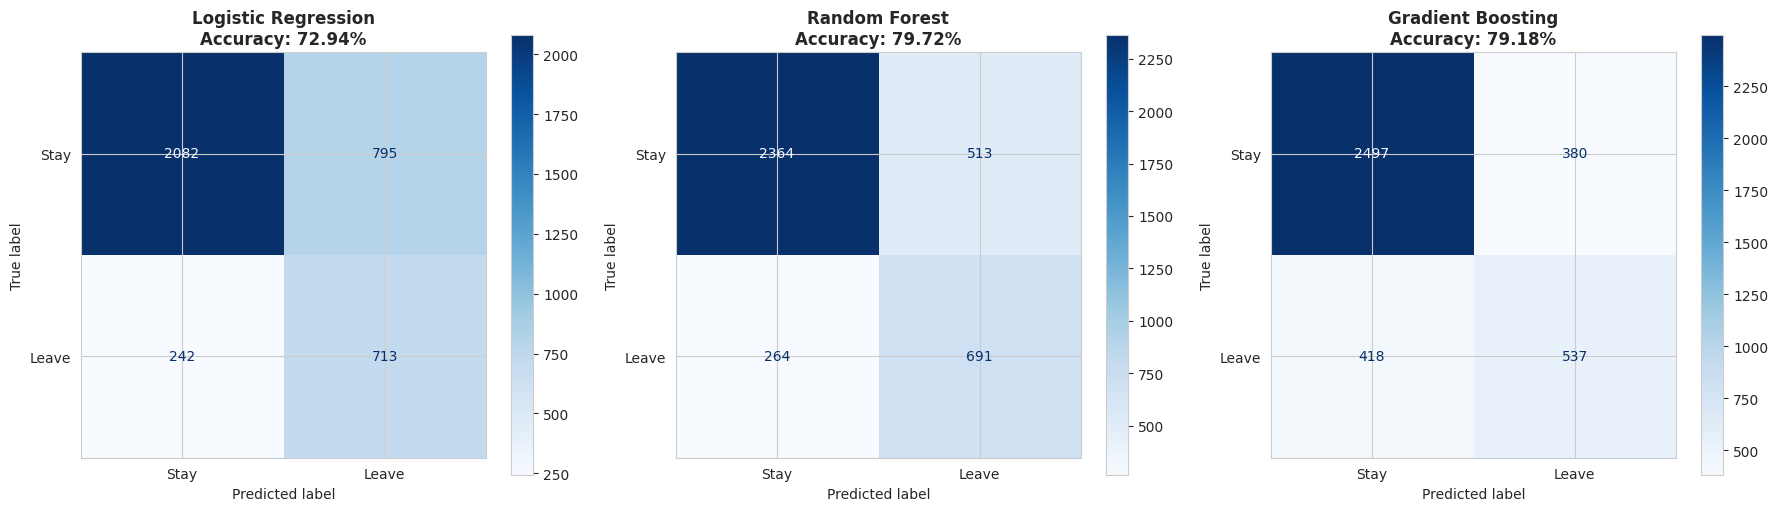

In [ ]:
# Confusion Matrices for All Three Models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
for i, name in enumerate(model_names):
    cm = confusion_matrix(y_val, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Stay', 'Leave'])
    disp.plot(cmap='Blues', ax=axes[i], values_format='d')
    acc = results[name]['accuracy']
    axes[i].set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')

plt.tight_layout()
plt.show()

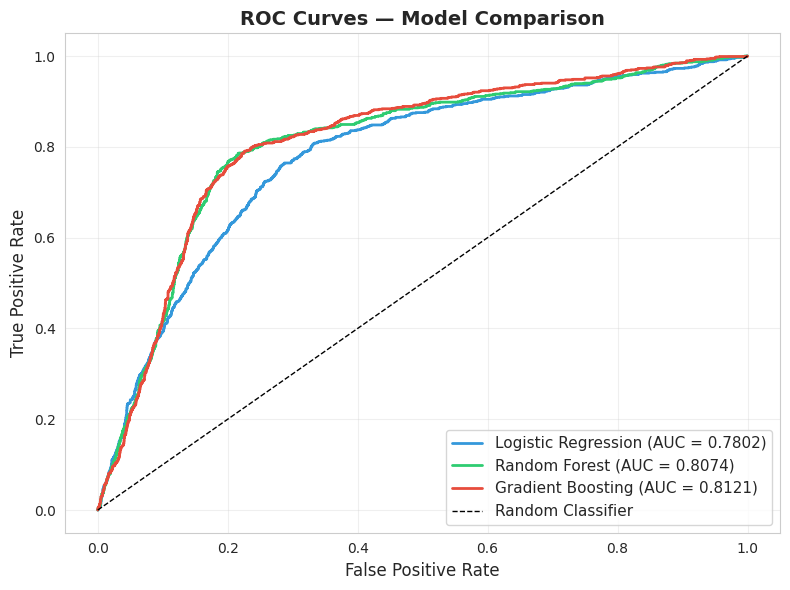

In [ ]:
# ROC Curves for All Three Models
plt.figure(figsize=(8, 6))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c']
for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_val, results[name]['y_prob'])
    auc = results[name]['auc']
    plt.plot(fpr, tpr, color=colors_roc[i], lw=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5-Fold Stratified Cross-Validation

Logistic Regression:
  Fold scores: [0.7247 0.7216 0.7315 0.7202 0.7327]
  Mean: 0.7261 (+/- 0.0051)

Random Forest:
  Fold scores: [0.7938 0.7954 0.7985 0.7943 0.805 ]
  Mean: 0.7974 (+/- 0.0041)

Gradient Boosting:
  Fold scores: [0.7902 0.7931 0.7915 0.7886 0.7927]
  Mean: 0.7912 (+/- 0.0017)


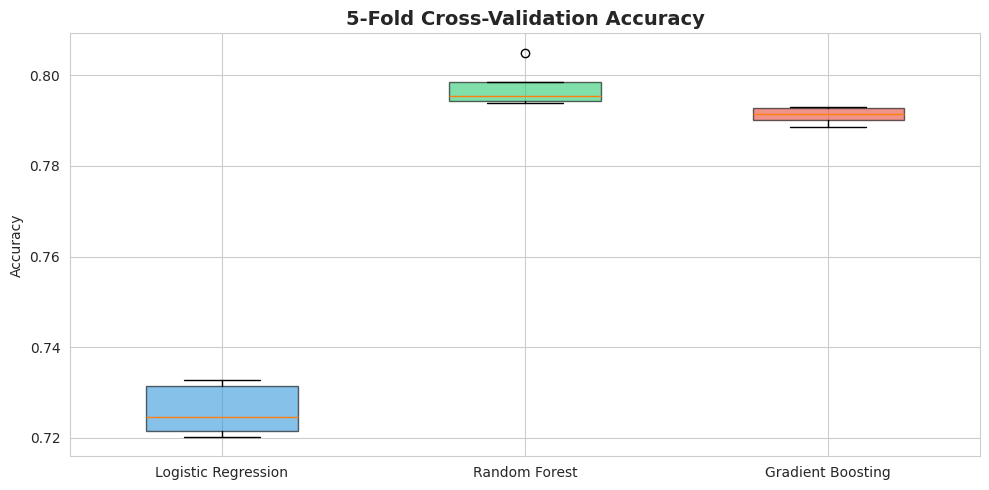

In [ ]:
# 5-Fold Stratified Cross-Validation on full training data
print("5-Fold Stratified Cross-Validation")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_full_scaled = scaler.fit_transform(X)

cv_results = {}
for name, model in [('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
                     ('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5,
                                                               min_samples_leaf=2, class_weight='balanced',
                                                               random_state=42, n_jobs=-1)),
                     ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                                       learning_rate=0.1, subsample=0.8,
                                                                       random_state=42))]:
    scores = cross_val_score(model, X_full_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"\n{name}:")
    print(f"  Fold scores: {scores.round(4)}")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Plot CV results
fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(cv_results))
bp = ax.boxplot([cv_results[name] for name in model_names],
                labels=model_names, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors_roc):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

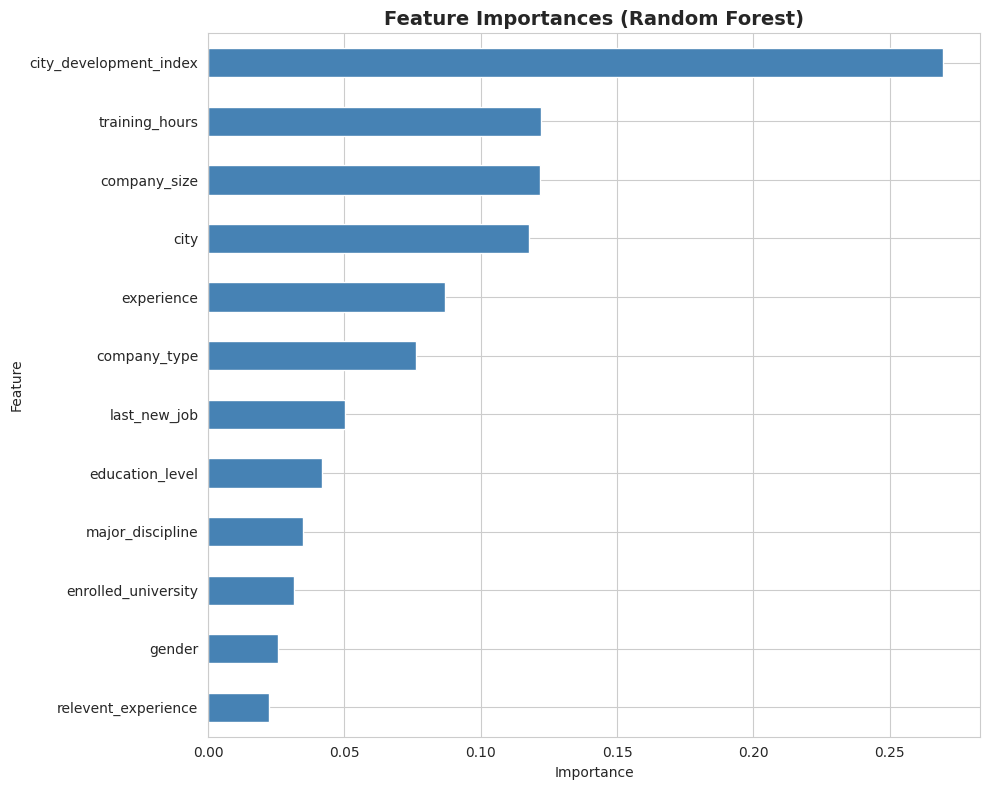


Top 5 Most Important Features:
  1. city_development_index: 0.2696
  2. training_hours: 0.1221
  3. company_size: 0.1217
  4. city: 0.1177
  5. experience: 0.0867


In [ ]:
# Feature Importance — Random Forest
feat_imp = pd.Series(
    models['Random Forest'].feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
for i, (feat, imp) in enumerate(feat_imp.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

<h2>🔮 Predictions on Test Set</h2>
<p>Using the best performing model to generate predictions on the unseen test data (<code>aug_test.csv</code>).</p>

In [ ]:
# Identify the best model
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]['accuracy']

print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {best_accuracy*100:.2f}%")

# Generate predictions on the test set
test_predictions = best_model.predict(X_test_scaled)
test_probabilities = best_model.predict_proba(X_test_scaled)[:, 1]

# Create submission dataframe
submission = pd.DataFrame({
    'enrollee_id': test_ids,
    'target': test_predictions
})

print(f"\nTest set predictions:")
print(f"  Stay (0):  {(test_predictions == 0).sum()}")
print(f"  Leave (1): {(test_predictions == 1).sum()}")

submission.head(10)

Best Model: Random Forest
Validation Accuracy: 79.72%

Test set predictions:
  Stay (0):  1483
  Leave (1): 646


,enrollee_id,target
0,32403,0
1,9858,0
2,31806,0
3,27385,0
4,27724,0
5,217,0
6,21465,1
7,27302,1
8,12994,0
9,16287,1


In [ ]:
# Save predictions to CSV
submission.to_csv('employee_predictions.csv', index=False)
print("Predictions saved to 'employee_predictions.csv'")

Predictions saved to 'employee_predictions.csv'





## 🧾 **Conclusions**

### 🔍 **Key Findings**

* The dataset is **imbalanced** (75% stay, 25% leave), handled using `class_weight='balanced'`.
* Candidates from **less developed cities** are more likely to switch jobs.
* Employees with **no relevant experience** show higher attrition.
* **Smaller companies/startups** have higher employee turnover.
* **Training hours** do not significantly impact job change.


## 🤖 **Model Comparison**

* **Logistic Regression:** Simple and fast, but cannot capture complex patterns.
* **Random Forest:** Handles non-linearity well and gives feature importance.
* **Gradient Boosting:** Highest accuracy but slower and sensitive to tuning.


## ⚙️ **Methodology**

1. Loaded and explored dataset (19,158 records)
2. Cleaned data and encoded categorical variables
3. Performed EDA with visualizations
4. Split data (80% train, 20% validation)
5. Trained 3 models
6. Evaluated using Accuracy, ROC-AUC, Confusion Matrix, Cross-validation
7. Selected best model and made predictions


## 🎯 **Final Conclusion**

The model can predict which employees are likely to leave, helping companies improve retention and plan hiring effectively.

